In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import shap

# Verify versions
print("Library Versions:")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"shap: {shap.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
# loads data directly from ProPublica GitHub - mo local file needed!
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)
df

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,...,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,...,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,Male,1958-10-01,57,Greater than 45,Other,...,1,Low,2014-01-14,2014-01-13,2014-01-14,0,0,808,0,0
7212,11000,farrah jean,farrah,jean,2014-03-09,Female,1982-11-17,33,25 - 45,African-American,...,2,Low,2014-03-09,2014-03-08,2014-03-09,3,0,754,0,0


In [3]:
#Distribution of key demographic and outcome variables
df_counts = {
    'race': df['race'].value_counts(),
    'sex': df['sex'].value_counts(),
    'age_cat': df['age_cat'].value_counts(),
    'two_year_recid': df['two_year_recid'].value_counts(),
    'score_text': df['score_text'].value_counts()
}

In [4]:
df_counts

{'race': race
 African-American    3696
 Caucasian           2454
 Hispanic             637
 Other                377
 Asian                 32
 Native American       18
 Name: count, dtype: int64,
 'sex': sex
 Male      5819
 Female    1395
 Name: count, dtype: int64,
 'age_cat': age_cat
 25 - 45            4109
 Greater than 45    1576
 Less than 25       1529
 Name: count, dtype: int64,
 'two_year_recid': two_year_recid
 0    3963
 1    3251
 Name: count, dtype: int64,
 'score_text': score_text
 Low       3897
 Medium    1914
 High      1403
 Name: count, dtype: int64}

In [5]:
# Calculates racial breakdown as percentages for EDA
df_race_pct = df['race'].value_counts(normalize=True) * 100
df_race_pct

,proportion
race,
African-American,51.233712
Caucasian,34.017189
Hispanic,8.830053
Other,5.225950
Asian,0.443582
Native American,0.249515


In [6]:
df_recid_pct = df['two_year_recid'].value_counts(normalize=True) * 100
df_recid_pct

,proportion
two_year_recid,
0,54.934849
1,45.065151


In [7]:
df_score_pct = df['score_text'].value_counts(normalize=True) * 100
df_score_pct

,proportion
score_text,
Low,54.019961
Medium,26.531744
High,19.448295


In [8]:
black_def = df[df['race'] == 'African-American']
white_def = df[df['race'] == 'Caucasian']

In [9]:
# Creates binary high risk indicator for groupby analysis
df['is_high_risk'] = (df['score_text'] == 'High')

df_comparison = df[df['race'].isin(['African-American', 'Caucasian','Asian','Hispanic', 'Native American', 'Other' ])].groupby('race').agg(
    recidivism_rate=('two_year_recid','mean'),
    avg_compas_score=('decile_score', 'mean'),
    high_risk_pct=('is_high_risk', 'mean')
)

# Compare recidivism rates, COMPAS scores, and high risk labels by race
df_comparison['recidivism_rate'] = (df_comparison['recidivism_rate'] * 100)
df_comparison['avg_compas_score'] = df_comparison['avg_compas_score']
df_comparison['high_risk_pct'] = (df_comparison['high_risk_pct'] * 100)

df_comparison.round(2)

,recidivism_rate,avg_compas_score,high_risk_pct
race,,,
African-American,51.43,5.37,27.73
Asian,28.12,2.94,9.38
Caucasian,39.36,3.74,11.25
Hispanic,36.42,3.46,10.52
Native American,55.56,6.17,33.33
Other,35.28,2.95,6.90


<Axes: title={'center': 'Recidivism Rate by Race'}, xlabel='Race', ylabel='Recidivism Rate (%)'>

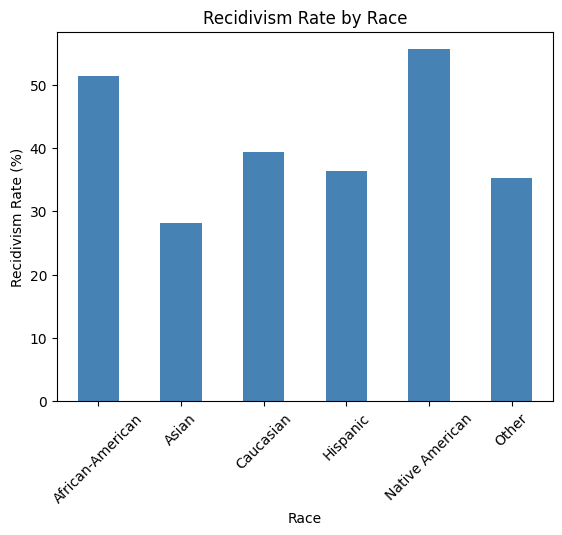

In [10]:
recid_by_race = df.groupby('race')['two_year_recid'].mean() * 100

# Visualization 1: Recidivism rate by race
recid_by_race.plot.bar(title='Recidivism Rate by Race', ylabel='Recidivism Rate (%)', xlabel='Race', color='steelblue', rot=45)

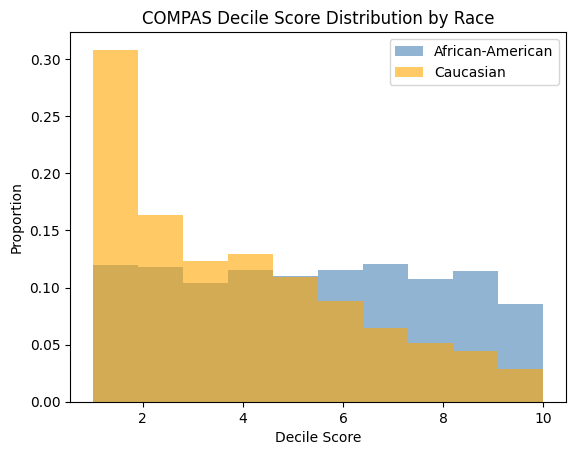

In [32]:
import matplotlib.pyplot as plt
# Visualization 3: COMPAS decile risk score distribution by race
# shows black defendants cluster toward higher scores than white defendants
fig, ax = plt.subplots()

df[df['race'] == 'African-American']['decile_score'].plot.hist(
    ax=ax, alpha=0.6, bins=10, label='African-American', color='steelblue', density=True
)
df[df['race'] == 'Caucasian']['decile_score'].plot.hist(
    ax=ax, alpha=0.6, bins=10, label='Caucasian', color='orange', density=True
)

ax.set_title('COMPAS Decile Score Distribution by Race')
ax.set_xlabel('Decile Score')
ax.set_ylabel('Proportion')
ax.legend()
plt.show()

<Axes: title={'center': 'COMPAS Risk Score Distribution by Race'}, xlabel='Race', ylabel='Percentage (%)'>

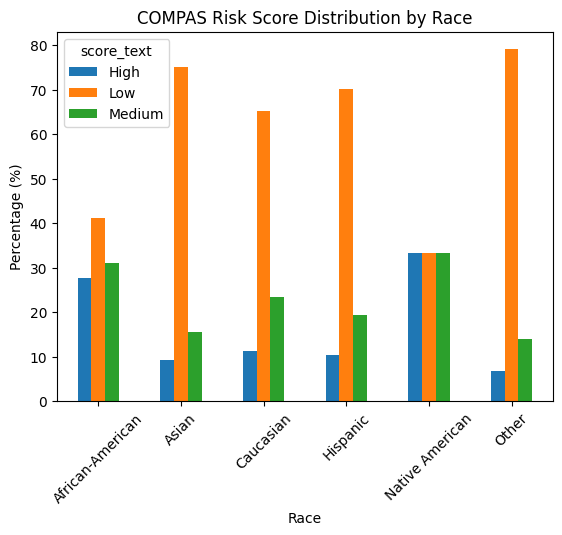

In [12]:
score_by_race = df.groupby('race')['score_text'].value_counts(normalize=True).unstack() * 100
# Visualization 2: COMPAS risk score distribution by race
score_by_race.plot.bar(title='COMPAS Risk Score Distribution by Race', ylabel='Percentage (%)', xlabel='Race',rot=45)

In [13]:
score_by_race = df.groupby('race')['score_text'].value_counts(normalize=True).unstack() * 100
score_by_race

score_text,High,Low,Medium
race,,,
African-American,27.732684,41.179654,31.087662
Asian,9.375000,75.000000,15.625000
Caucasian,11.246944,65.199674,23.553382
Hispanic,10.518053,70.172684,19.309262
Native American,33.333333,33.333333,33.333333
Other,6.896552,79.045093,14.058355


In [33]:
# Select features for Random Forest model
# race and sex are one-hot encoded via pd.get_dummies
features = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'sex', 'race']
target = 'two_year_recid' #Binary: 0 = no reoffend, 1 = reoffend within 2 years

df_model = df[features + [target]].dropna()

df_model = pd.get_dummies(df_model, columns=['sex', 'race'])

print(df_model.shape)
print(df_model.columns.tolist())

(7214, 13)
['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'two_year_recid', 'sex_Female', 'sex_Male', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']


In [34]:
from sklearn.model_selection import train_test_split

features = ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'sex', 'race']
target = 'two_year_recid'

df_model = df[features + [target]].dropna()
df_model = pd.get_dummies(df_model, columns=['sex', 'race'])

X = df_model.drop(columns=[target])
y = df_model[target]

#80/20 train/test split with fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (5771, 12)
Test size: (1443, 12)


In [35]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest - 100 trees, random_state=42
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [17]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Baseline performance metrics - overall and disaggregated by race
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.69      0.70      0.69       823
           1       0.59      0.58      0.59       620

    accuracy                           0.65      1443
   macro avg       0.64      0.64      0.64      1443
weighted avg       0.65      0.65      0.65      1443

AUC-ROC: 0.6801885313369654


In [18]:
# Add predictions back to test set for group analysis
X_test_copy = X_test.copy()
X_test_copy['y_true'] = y_test.values
X_test_copy['y_pred'] = y_pred

# Accuracy per racial group
def accuracy_by_group(df, race_col):
    df['correct'] = df['y_true'] == df['y_pred']
    return df.groupby(race_col)['correct'].mean()

accuracy_by_group(X_test_copy, 'race_African-American')

,correct
race_African-American,
False,0.650281
True,0.647059


In [19]:
# Add race back from original df using index
X_test_copy['race'] = df.loc[X_test.index, 'race'].values

# disaggregated metrics function
def metrics_by_group(df, group_col):
    df['correct'] = df['y_true'] == df['y_pred']
    return df.groupby(group_col).agg(
        accuracy=('correct', 'mean'),
        count=('correct', 'count')
    )
# Disaggregagted accuracy by racial group
# Note: Asian (n=5) and Native American (n=3) have small sample si
metrics_by_group(X_test_copy, 'race')

,accuracy,count
race,,
African-American,0.647059,731
Asian,0.600000,5
Caucasian,0.651485,505
Hispanic,0.632479,117
Native American,0.666667,3
Other,0.670732,82


In [20]:
#race back to test set
X_test_copy['race'] = df.loc[X_test.index, 'race'].values

#fairness metrics function
def fairness_metrics(df, group_col, group1, group2):
    g1 = df[df[group_col] == group1]
    g2 = df[df[group_col] == group2]

    results = pd.DataFrame({
        'metric': ['demographic_parity', 'false_positive_rate', 'false_negative_rate', 'predictive_parity'],
        group1: [
            g1['y_pred'].mean(),
            (g1[(g1['y_true'] == 0) & (g1['y_pred'] == 1)].shape[0] / g1[g1['y_true'] == 0].shape[0]),
            (g1[(g1['y_true'] == 1) & (g1['y_pred'] == 0)].shape[0] / g1[g1['y_true'] == 1].shape[0]),
            (g1[(g1['y_true'] == 1) & (g1['y_pred'] == 1)].shape[0] / g1[g1['y_pred'] == 1].shape[0])
        ],
        group2: [
            g2['y_pred'].mean().round(3),
            (g2[(g2['y_true'] == 0) & (g2['y_pred'] == 1)].shape[0] / g2[g2['y_true'] == 0].shape[0]),
            (g2[(g2['y_true'] == 1) & (g2['y_pred'] == 0)].shape[0] / g2[g2['y_true'] == 1].shape[0]),
            (g2[(g2['y_true'] == 1) & (g2['y_pred'] == 1)].shape[0] / g2[g2['y_pred'] == 1].shape[0])
        ]
    })
    return results

fairness_metrics(X_test_copy, 'race', 'African-American', 'Caucasian')

,metric,African-American,Caucasian
0,demographic_parity,0.511628,0.343000
1,false_positive_rate,0.362117,0.256250
2,false_negative_rate,0.344086,0.508108
3,predictive_parity,0.652406,0.526012


In [21]:
!pip install shap -q
import shap

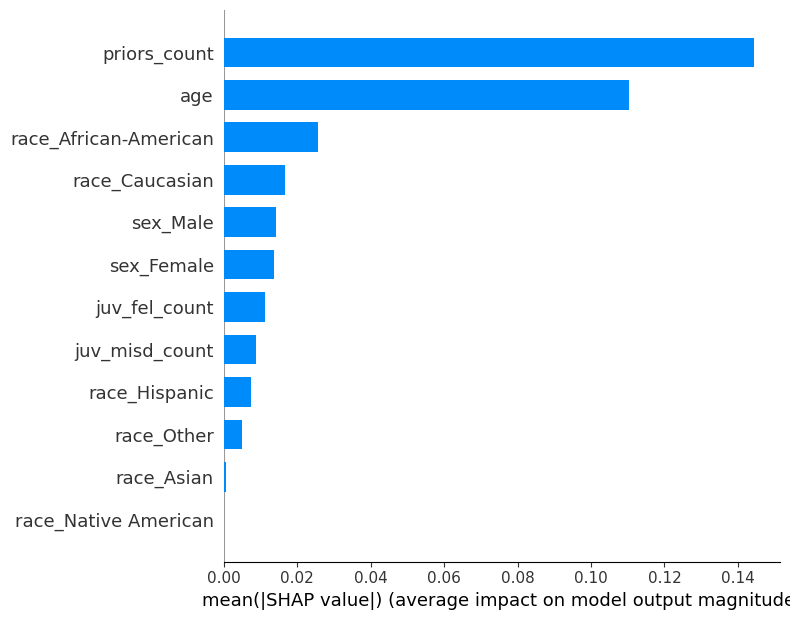

In [22]:
X_test_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test_sample)

shap.summary_plot(shap_explanation[:,:,1], X_test_sample, plot_type="bar")


In [23]:
# Find a Black defendant predicted high risk who did not reoffend (false positive)
X_test_copy['race'] = df.loc[X_test.index, 'race'].values

false_positives = X_test_copy[
    (X_test_copy['race'] == 'African-American') &
    (X_test_copy['y_true'] == 0) &
    (X_test_copy['y_pred'] == 1)
]

# Pick the first one
individual = false_positives.iloc[0]
print(individual)

age                                    22
priors_count                            3
juv_fel_count                           0
juv_misd_count                          0
sex_Female                          False
sex_Male                             True
race_African-American                True
race_Asian                          False
race_Caucasian                      False
race_Hispanic                       False
race_Native American                False
race_Other                          False
y_true                                  0
y_pred                                  1
correct                             False
race                     African-American
Name: 676, dtype: object


In [24]:
# Test what changes would flip the prediction
individual_features = false_positives.iloc[[0]].drop(
    columns=['y_true', 'y_pred', 'correct', 'race']
)

print("Original prediction:", model.predict(individual_features)[0])

# What if priors_count was 0?
individual_no_priors = individual_features.copy()
individual_no_priors['priors_count'] = 0
print("With 0 priors:", model.predict(individual_no_priors)[0])

# What if they were older?
individual_older = individual_features.copy()
individual_older['age'] = 40
print("With age 40:", model.predict(individual_older)[0])

# What if race was Caucasian?
individual_white = individual_features.copy()
individual_white['race_African-American'] = False
individual_white['race_Caucasian'] = True
print("If Caucasian:", model.predict(individual_white)[0])

Original prediction: 1
With 0 priors: 1
With age 40: 1
If Caucasian: 1


In [25]:
# What if multiple things changed at once?
individual_combined = individual_features.copy()
individual_combined['priors_count'] = 0
individual_combined['age'] = 40
individual_combined['race_African-American'] = False
individual_combined['race_Caucasian'] = True
print("0 priors + age 40 + Caucasian:", model.predict(individual_combined)[0])

# Try just age + priors
individual_age_priors = individual_features.copy()
individual_age_priors['priors_count'] = 0
individual_age_priors['age'] = 35
print("0 priors + age 35:", model.predict(individual_age_priors)[0])

0 priors + age 40 + Caucasian: 0
0 priors + age 35: 0


In [26]:
age_influence= df.groupby("age_cat")["two_year_recid"].mean()*100
age_influence

,two_year_recid
age_cat,
25 - 45,45.972256
Greater than 45,31.598985
Less than 25,56.507521


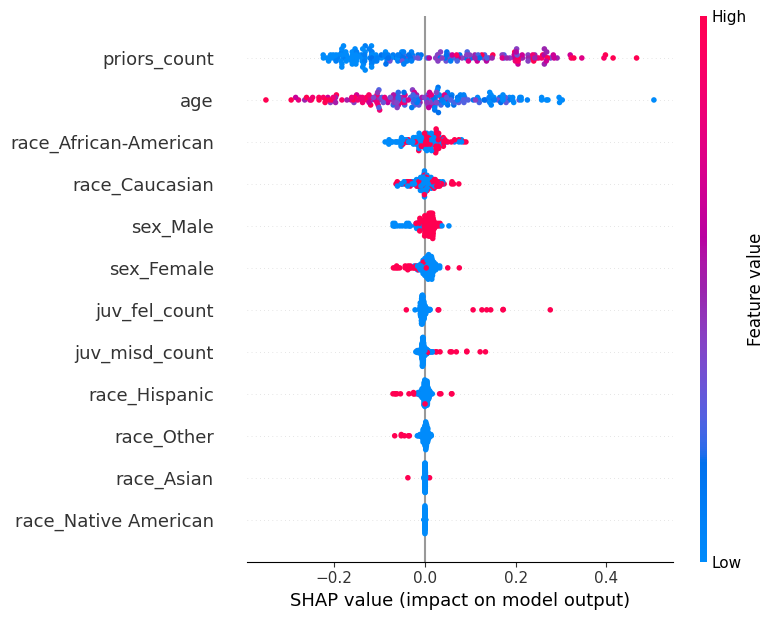

In [27]:
# What drives Caucasian predictions vs African-American
shap.summary_plot(shap_explanation[:,:,1], X_test_sample)

In [28]:
priors_by_race = df.groupby('race')['priors_count'].mean().sort_values(ascending=False)
priors_by_race

,priors_count
race,
Native American,6.000000
African-American,4.438853
Caucasian,2.586797
Hispanic,2.252747
Other,1.875332
Asian,1.437500


In [29]:
compas_vs_actual = df.groupby('race').agg(
    avg_compas_score=('decile_score', 'mean'),
    actual_recidivism=('two_year_recid', 'mean')
).round(3)
compas_vs_actual['actual_recidivism'] = (compas_vs_actual['actual_recidivism'] * 100).round(1)
compas_vs_actual

,avg_compas_score,actual_recidivism
race,,
African-American,5.369,51.4
Asian,2.938,28.1
Caucasian,3.735,39.4
Hispanic,3.463,36.4
Native American,6.167,55.6
Other,2.950,35.3


In [4]:
X_test_copy['sex'] = df.loc[X_test.index, 'sex'].values

fp_intersectional = X_test_copy[
    (X_test_copy['y_true'] == 0) &
    (X_test_copy['y_pred'] == 1)
].groupby(['race', 'sex']).size().unstack().fillna(0)

fp_intersectional

NameError: name 'df' is not defined

In [3]:
# ============================================================
# Requirements Summary
# ============================================================
# pandas
# numpy
# scikit-learn
# matplotlib
# seaborn
# shap
#
# To reproduce: Run all cells top to bottom in jupyter notebook
# Data loads automatically from GitHub URL - no local files needed
# random_state=42 used throughout for reproducibility
# ============================================================